MUSICAL TRENDS OF 21ST CENTURY: THE STREAMING AGE

How have consumerism and music production evolved during the last two decades?
The main goal of this project is to analyze the evolution of music comsumption habits and musical production during the 21st century, extracting structural patterns that delinate the success in the digital era to guide strategies of music production and audience detection.

This analysis uses the following dataset, available at:
https://www.kaggle.com/datasets/amitanshjoshi/spotify-1million-tracks/data 
Then, we will use: SQL, Pandas, Matplotlib and Seaborn that will be useful for cleaning, consulting and visualizating data.

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

The style of this notebook's graphs will be "Dark Mode"

In [3]:
plt.style.use('dark_background')
sns.set_palette(['#00d8ff', '#ff6600', '#aaaaaa']) 
plt.rcParams['figure.facecolor'] = '#121212'
plt.rcParams['axes.facecolor'] = '#121212'
plt.rcParams['axes.grid'] = False 
plt.rcParams['axes.edgecolor'] = '#333333'

We will start reading of the database and map the "key" columns that contains values from 0 to 11 that represent the 12 tonalities of music, it means:
C, C#/Db, D, D#/Eb, E, F, F#/Gb, G, G#/Ab, A, A#/Bb and B

In [5]:
df = pd.read_csv('spotify_data.csv')

# Mapeamos los tonos de la API de Spotify a notación musical real
mapeo_tonos = {
    0: 'C', 1: 'C#/Db', 2: 'D', 3: 'D#/Eb', 4: 'E', 5: 'F', 
    6: 'F#/Gb', 7: 'G', 8: 'G#/Ab', 9: 'A', 10: 'A#/Bb', 11: 'B'
}
# Creamos una columna nueva y legible
df['musical_note'] = df['key'].map(mapeo_tonos)

In [7]:
conexion = sqlite3.connect(':memory:')
df.to_sql('spotify_db', conexion, index=False)

print(f"The databse has {len(df)} songs!")
print("Musical tonalities are ready!")

The databse has 1159764 songs!
Musical tonalities are ready!


The next query is to count how many songs use a note as their tonal center (key)

In [38]:
QUERY = """
    SELECT musical_note, COUNT(*) AS count_
    FROM spotify_db GROUP BY musical_note
    ORDER BY count_ DESC
    """ 
df_tonos = pd.read_sql_query(QUERY, conexion)
print(df_tonos.head(12))

   musical_note  count_
0             G  139635
1             C  130081
2             D  123690
3             A  119293
4         C#/Db  112806
5             F   94032
6             E   91170
7             B   90955
8         F#/Gb   76120
9         A#/Bb   76038
10        G#/Ab   70206
11        D#/Eb   35738


We better see it!

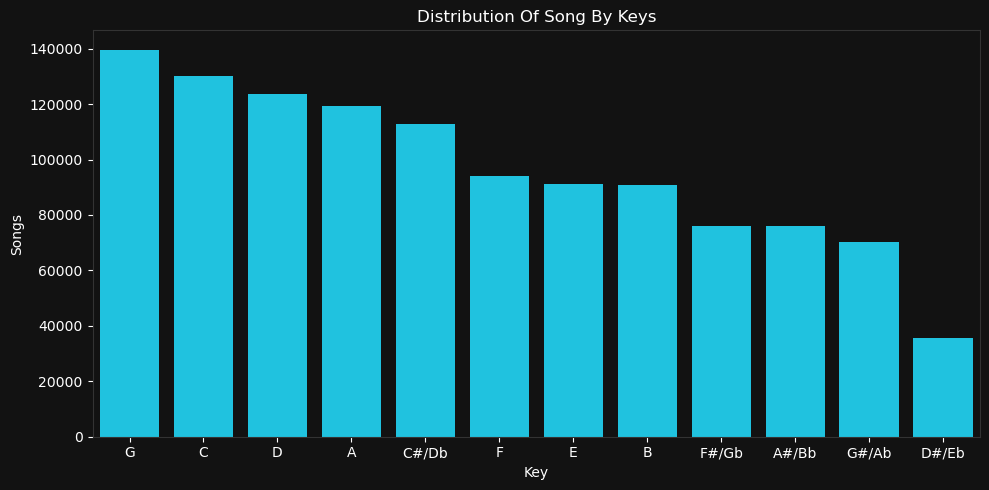

In [40]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df_tonos,
    x='musical_note',
    y='count_',
    color="#00d8ff"
)
plt.title('Distribution Of Song By Keys')
plt.xlabel('Key')
plt.ylabel('Songs')
plt.tight_layout()
plt.show()

In this graph, it is possible to notice that the four most popular keys are natural, it means, that they present little alterations in their major or minor scale, such as, G, C, D and A.  
On the other hand, the four lest popular keys have more altered notes in their scales. This can be explained if we consider the majority of chord instruments are tuned with natural notes, suchs as, guitars, it makes the execution and writing easier for musicians and composers respectively for creating a song.

However, it is necessary to be more specific for a key can be "major" or "minor", it means, G (GM) or Gm. To explain it better, major keys sound "happier" while minor keys "sader" or more "subdued".  
Then, when a key is major, we'll use an 'M' and an 'm' if it is minor.
In the database, there is a columns named 'mode' with numers 0 and 1 that represent minor and major respectively.

In [12]:
df['tone_mode'] = df['mode'].map({1: 'M', 0: 'm'})
df.to_sql('spotify_db', conexion, if_exists='replace', index=False)

1159764

Now, we will join column 'musical_note' (that was extracted before from 'key') and 'tone_mode' (that will be done from 'mode') into a new column named 'tonality', in this way, we can see major and minor keys better.

In [14]:
QUERY1 = """
    SELECT musical_note, tone_mode, 
    (musical_note || tone_mode) AS tonality,
    COUNT(*) AS count_
    FROM spotify_db
    GROUP BY musical_note, tone_mode
    ORDER BY count_ DESC
    """
df_mode_keys = pd.read_sql_query(QUERY1, conexion)

In [18]:
print("Columns of df_mode_tone:", df_mode_keys.columns.tolist()) 
print(df_mode_keys.head())

Columns of df_mode_tone: ['musical_note', 'tone_mode', 'tonality', 'count_']
  musical_note tone_mode tonality  count_
0            G         M       GM  108715
1            C         M       CM  101824
2            D         M       DM   95027
3        C#/Db         M   C#/DbM   80219
4            A         M       AM   69237


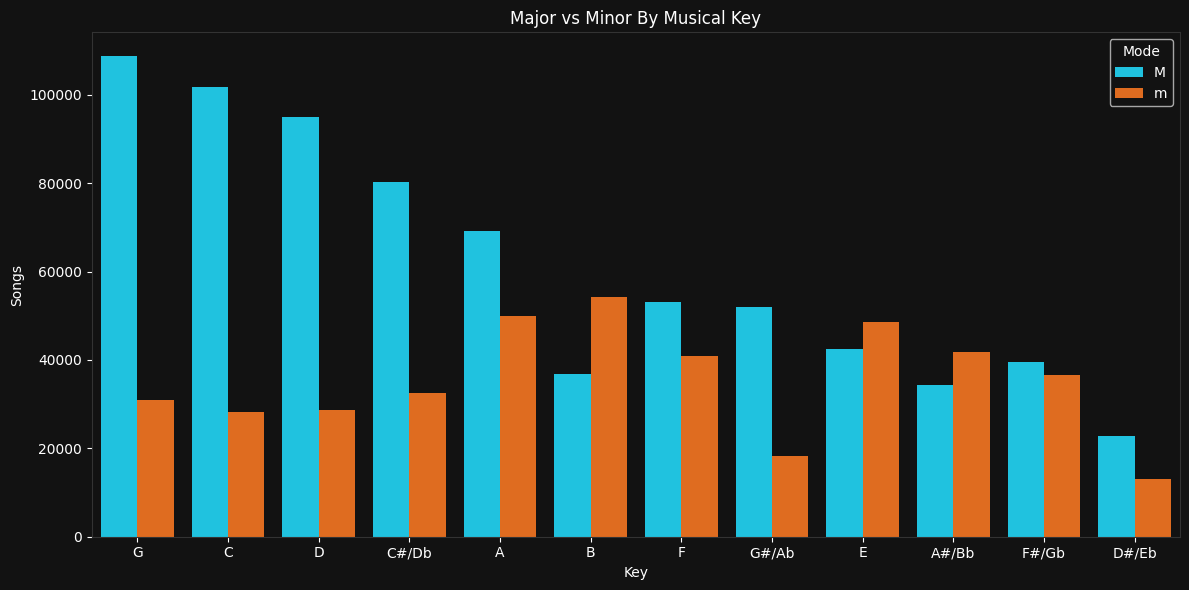

In [19]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=df_mode_keys,
    x='musical_note',
    y='count_',
    hue='tone_mode',
    palette=['#00d8ff', '#ff6600']
)
plt.title('Major vs Minor By Musical Key')
plt.xlabel('Key') 
plt.ylabel('Songs') 
plt.legend(title='Mode') 
plt.tight_layout() 
plt.show()

With this graph we can be surer about the conclusion of the first one: most popular tonalities have little alterations.  
-G has one alteration in its major scale and two in its minor scale.  
-C has no alteration in its major scale and three in its minor scale.  
-D has two alterations in its major scale and one in its minor scale.  
-A has three alteration in its major scale and zero in its minor scale.  
Nevertheless, C# major has all its notes altered in its scale (seven) is more used than A major, this may be possible due to C# tonality is the same as C that has no sharps (# alterations), it means, C# scale is just alter all notes of C scale.

On the other hand, B, E and A#/Bb are more used as minor than major, again, this can be explained with the quantity of alterations in their scales.  
-B major has five alterations, while Bm has only two, the same as D major.  
-E major has four alterations, while Em has only two, the same as G major.  
-However, we've got a paradox with Bb because it only has two alterations in its major scale, but five in its minor scale and this is more used.  
So, the choice of a specific key has various factores: kind of voice of the singer, facility of execution in some instruments and election of the composer for transmiting something.

Now, from this point we'll see the main trends by quinquennial, it means, we'll see the TOP 20 of music genres in streming every five years.
So, we ought to modify the table and create a column named 'quinquennial' with SQL.

In [11]:
conexion.execute("ALTER TABLE spotify_db ADD COLUMN quinquennial TEXT")

conexion.execute("""
    UPDATE spotify_db 
    SET quinquennial = (year - (year % 5)) || '-' || ((year - (year % 5)) + 4)
""")

conexion.commit()

print("¡Column 'quinquennial' created and saved in SQL!")

¡Column 'quinquennial' created and saved in SQL!


In [44]:
QUERY6 = """
    SELECT genre, SUM(popularity) AS total_popularity, quinquennial 
    FROM spotify_db 
    WHERE quinquennial = '2000-2004'
    GROUP BY genre
    ORDER BY total_popularity DESC
    LIMIT 20
    """
quinquennial00_04 = pd.read_sql_query(QUERY6, conexion)
quinquennial00_04

,genre,total_popularity,quinquennial
0,alt-rock,153117,2000-2004
1,dance,124371,2000-2004
2,classical,94115,2000-2004
3,country,89426,2000-2004
4,hardcore,86816,2000-2004
5,hip-hop,83029,2000-2004
6,folk,78961,2000-2004
7,jazz,73287,2000-2004
8,blues,67024,2000-2004
9,pop,65989,2000-2004


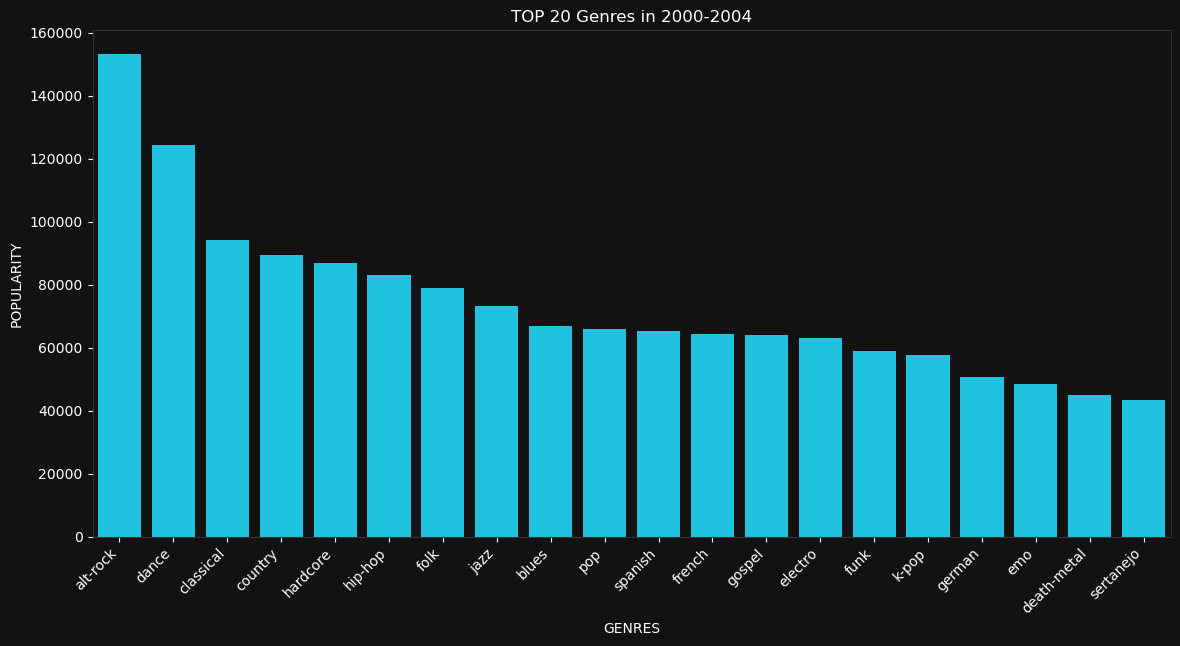

In [46]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=quinquennial00_04,
    x="genre",
    y="total_popularity",
    color='#00d8ff'
)
plt.title('TOP 20 Genres in 2000-2004')
plt.xlabel('GENRES') 
plt.ylabel('POPULARITY') 
plt.tight_layout() 
plt.xticks(rotation=45, ha='right')
plt.show()

In this graph, we can observe that Alt-Rock is in top 1, however, it may be surprising that Classical Music is in top 3, because this type of music is not "well appreciated".  
Songs in other languages such as, Spanish, French, Korean (K-Pop), German and Portuguese with Sertanejo from Brazil were musical trends in countries where those langagues are not spoken.

In [48]:
QUERY7 = """
    SELECT genre, SUM(popularity) AS total_popularity, quinquennial 
    FROM spotify_db 
    WHERE quinquennial  = '2005-2009'
    GROUP BY genre
    ORDER BY total_popularity DESC
    LIMIT 20
    """
quinquennial05_09 = pd.read_sql_query(QUERY7, conexion)
quinquennial05_09

,genre,total_popularity,quinquennial
0,alt-rock,159463,2005-2009
1,dance,133709,2005-2009
2,hip-hop,112241,2005-2009
3,country,98287,2005-2009
4,folk,91888,2005-2009
5,classical,89847,2005-2009
6,jazz,82637,2005-2009
7,electro,80987,2005-2009
8,spanish,80038,2005-2009
9,blues,78358,2005-2009


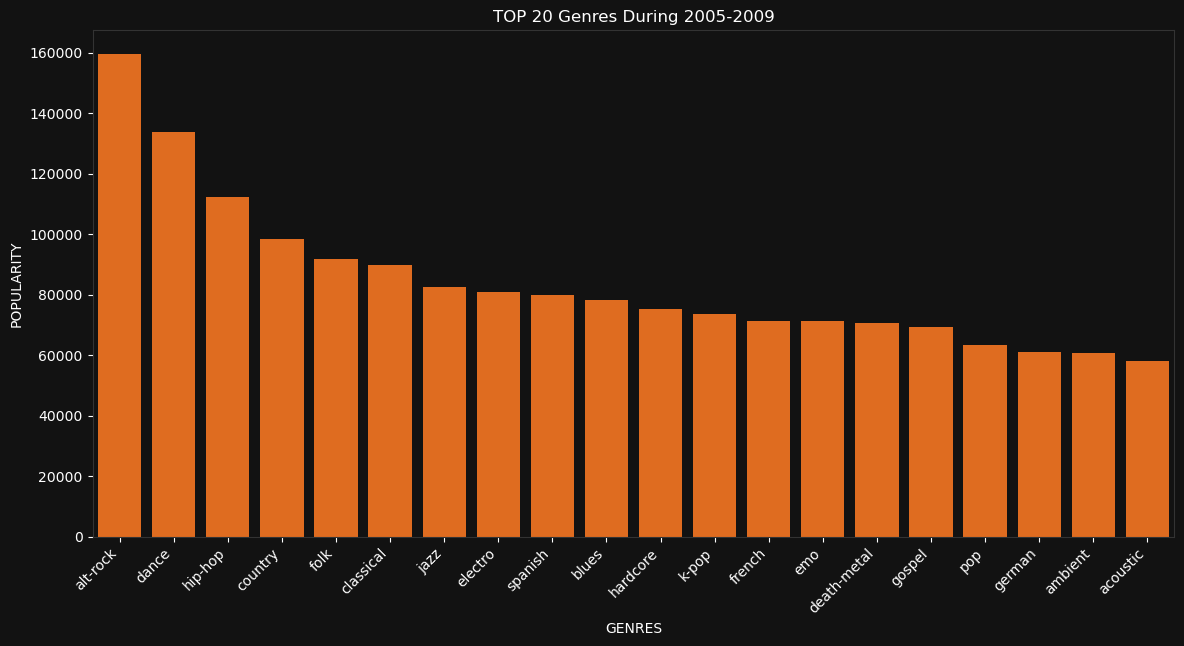

In [50]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=quinquennial05_09,
    x="genre",
    y="total_popularity",
    color='#ff6600'
)
plt.title('TOP 20 Genres During 2005-2009')
plt.xlabel('GENRES') 
plt.ylabel('POPULARITY') 
#plt.legend(title='Modo') 
plt.tight_layout() 
plt.xticks(rotation=45, ha='right')
plt.show()

The Ambient and Acoustic genres replace Funk and Sertanejo in the TOP 20 of this quinquennial.  
Meanwhile, Emo and Death-metal genres improved when compared to the last quinquennial.  
Lastly, music in other languages such as, Spanish, French and German also improved in the top of this quinquennial.

In [52]:
QUERY8 = """
    SELECT genre, SUM(popularity) AS total_popularity, quinquennial 
    FROM spotify_db 
    WHERE quinquennial = '2010-2014'
    GROUP BY genre
    ORDER BY total_popularity DESC
    LIMIT 20
    """
quinquennial10_14 = pd.read_sql_query(QUERY8, conexion)
quinquennial10_14

,genre,total_popularity,quinquennial
0,alt-rock,168311,2010-2014
1,dance,158718,2010-2014
2,hip-hop,144080,2010-2014
3,country,127246,2010-2014
4,folk,112072,2010-2014
5,k-pop,107676,2010-2014
6,chill,106093,2010-2014
7,emo,97723,2010-2014
8,classical,95808,2010-2014
9,french,94113,2010-2014


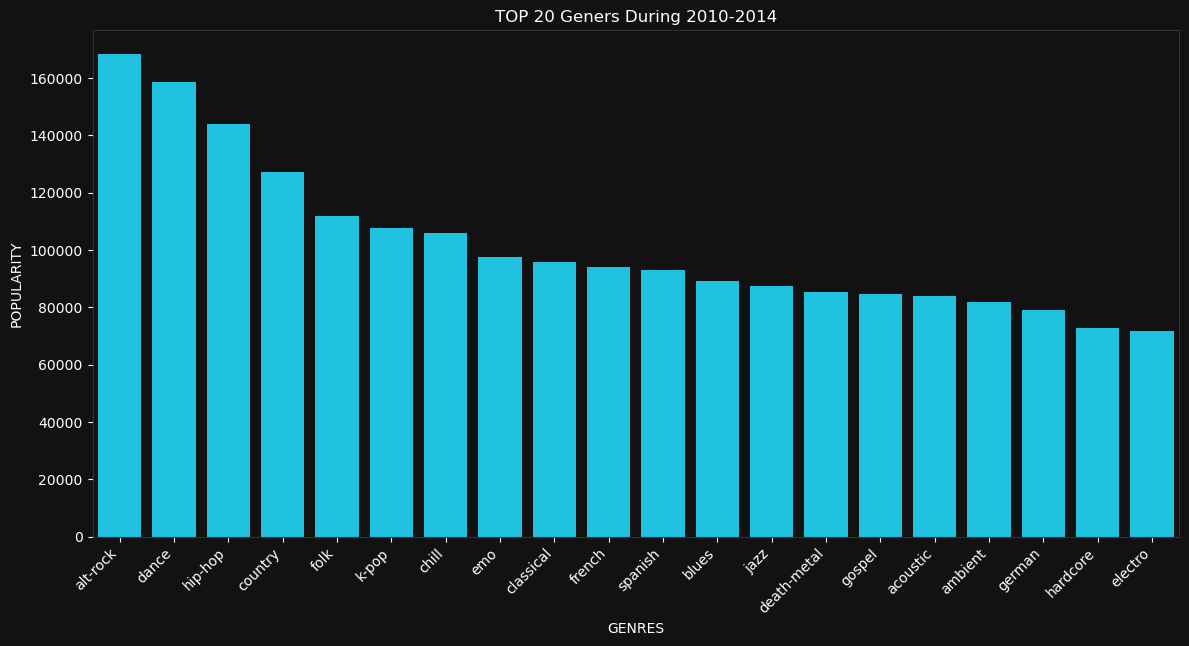

In [54]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=quinquennial10_14,
    x="genre",
    y="total_popularity",
    color='#00d8ff'
)
plt.title('TOP 20 Geners During 2010-2014')
plt.xlabel('GENRES') 
plt.ylabel('POPULARITY') 
#plt.legend(title='Modo') 
plt.tight_layout() 
plt.xticks(rotation=45, ha='right')
plt.show()

Chill appeared inside TOP 10, on the other hand, Pop-Film appeared in TOP 20.  
Music produced in French overcame Spanish music.

In [25]:
QUERY9 = """
    SELECT genre, SUM(popularity) AS total_popularity, quinquennial 
    FROM spotify_db 
    WHERE quinquennial = '2015-2019'
    GROUP BY genre
    ORDER BY total_popularity DESC
    LIMIT 20
    """
quinquennial15_19 = pd.read_sql_query(QUERY9, conexion)
quinquennial15_19

,genre,total_popularity,quinquennial
0,hip-hop,224935,2015-2019
1,alt-rock,195231,2015-2019
2,chill,179521,2015-2019
3,dance,176433,2015-2019
4,k-pop,167672,2015-2019
5,emo,154238,2015-2019
6,folk,149024,2015-2019
7,country,144133,2015-2019
8,ambient,138828,2015-2019
9,french,137505,2015-2019


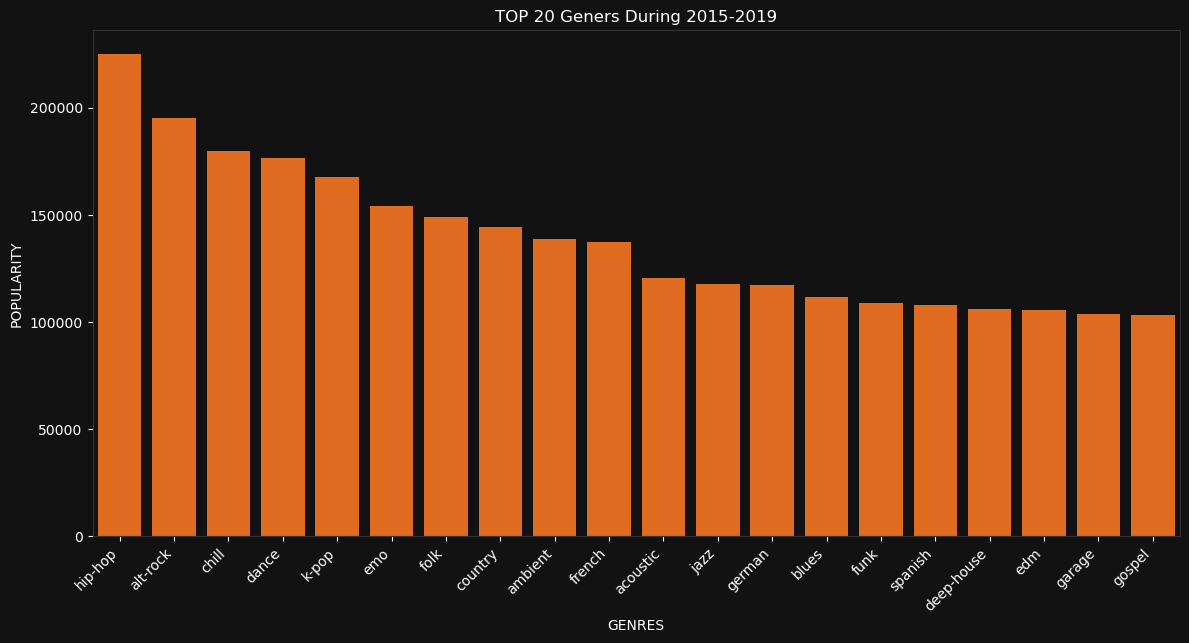

In [56]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=quinquennial15_19,
    x="genre",
    y="total_popularity",
    color='#ff6600'
)
plt.title('TOP 20 Geners During 2015-2019')
plt.xlabel('GENRES') 
plt.ylabel('POPULARITY') 
#plt.legend(title='Modo') 
plt.tight_layout() 
plt.xticks(rotation=45, ha='right')
plt.show()

-Alt-Rock lost the leadership against Hip-Hop, while K-Pop and Chill get in TOP 5.  
-Funk appeared again in TOP 20  
-Songs in French and German overcame Spanish songs.  
-Deep-House, EDM and Garage got in TOP 20.  
-Death-Metal, Ambient, Classical Music and Hardcore disappeared from TOP 20.

In [30]:
QUERY10 = """
    SELECT genre, SUM(popularity) AS total_popularity, quinquennial 
    FROM spotify_db 
    WHERE quinquennial = '2020-2024'
    GROUP BY genre
    ORDER BY total_popularity DESC
    LIMIT 20
    """
quinquennial20_24 = pd.read_sql_query(QUERY10, conexion)
quinquennial20_24

,genre,total_popularity,quinquennial
0,hip-hop,163011,2020-2024
1,chill,156939,2020-2024
2,k-pop,148184,2020-2024
3,dance,147476,2020-2024
4,country,131895,2020-2024
5,alt-rock,131246,2020-2024
6,sad,127656,2020-2024
7,jazz,124212,2020-2024
8,french,122721,2020-2024
9,emo,121298,2020-2024


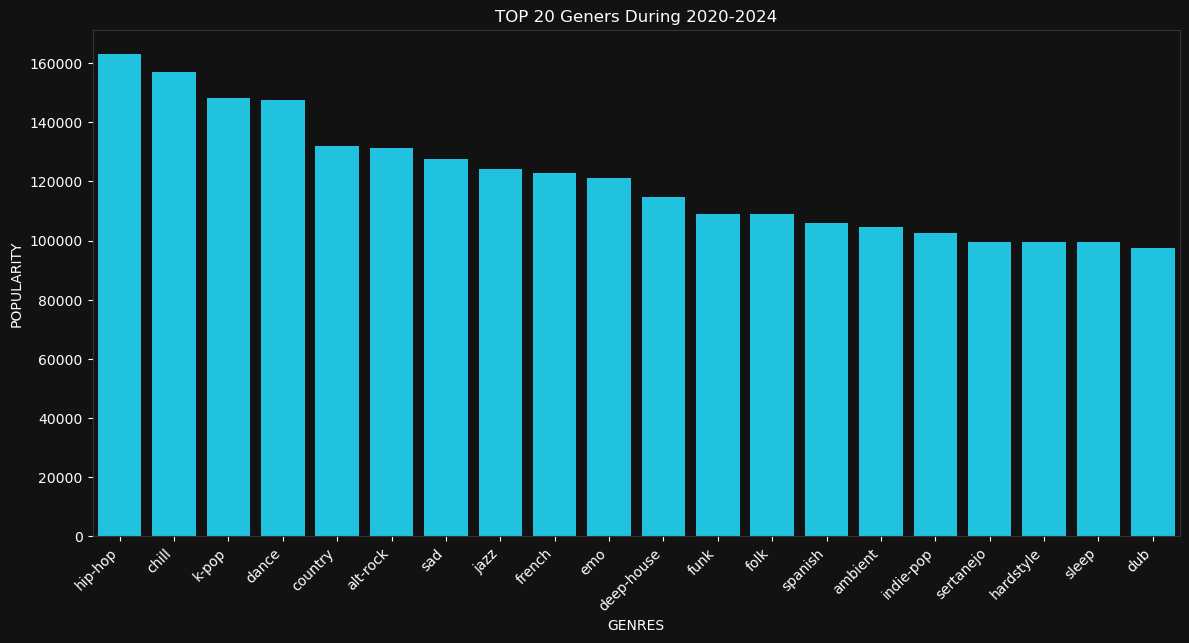

In [58]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=quinquennial20_24,
    x="genre",
    y="total_popularity",
    color='#00d8ff'
)
plt.title('TOP 20 Geners During 2020-2024')
plt.xlabel('GENRES') 
plt.ylabel('POPULARITY') 
#plt.legend(title='Modo') 
plt.tight_layout() 
plt.xticks(rotation=45, ha='right')
plt.show()

-Alt-Rock is not in TOP 5 for the first time.  
-Sad music got in TOP 10.  
-Sleep, Hardstyle, Dub and Indie-Pop got in TOP 20.  
-German music is not in TOP 20 for the first time.  
-Sertanejo y Ambient reappeared in TOP 20.  
-Folk music is out of TOP 20 for the first time.  
-Hip-Hop is the most popular genre, but, it didn't break its own record of the last quinquennial (we must consider data is until 2023)

In this point, we'll analyze the average duration of songs, in the database this is shown in milliseconds (ms), that's why we'll create a column named 'duration_min' to see the duration by minutes so that we understand better the information.

In [65]:
QUERY11 = """
    SELECT duration_ms, 
    (duration_ms/60000.0) AS duration_min
    FROM spotify_db
    """
duration_songs = pd.read_sql_query(QUERY11, conexion)
duration_songs

,duration_ms,duration_min
0,240166,4.002767
1,216387,3.606450
2,158960,2.649333
3,304293,5.071550
4,244320,4.072000
...,...,...
1159759,344013,5.733550
1159760,285067,4.751117
1159761,214253,3.570883
1159762,239133,3.985550


Now, let's see the mean duration of songs by year.

In [67]:
QUERY12 = """
    SELECT  year, 
    AVG(duration_ms / 60000.0) AS average_minutes
    FROM spotify_db
    GROUP BY year
    ORDER BY year ASC
    """
average_min = pd.read_sql_query(QUERY12, conexion)
average_min

,year,average_minutes
0,2000,4.331459
1,2001,4.365222
2,2002,4.388925
3,2003,4.316647
4,2004,4.306355
5,2005,4.361092
6,2006,4.386501
7,2007,4.415313
8,2008,4.398722
9,2009,4.427241


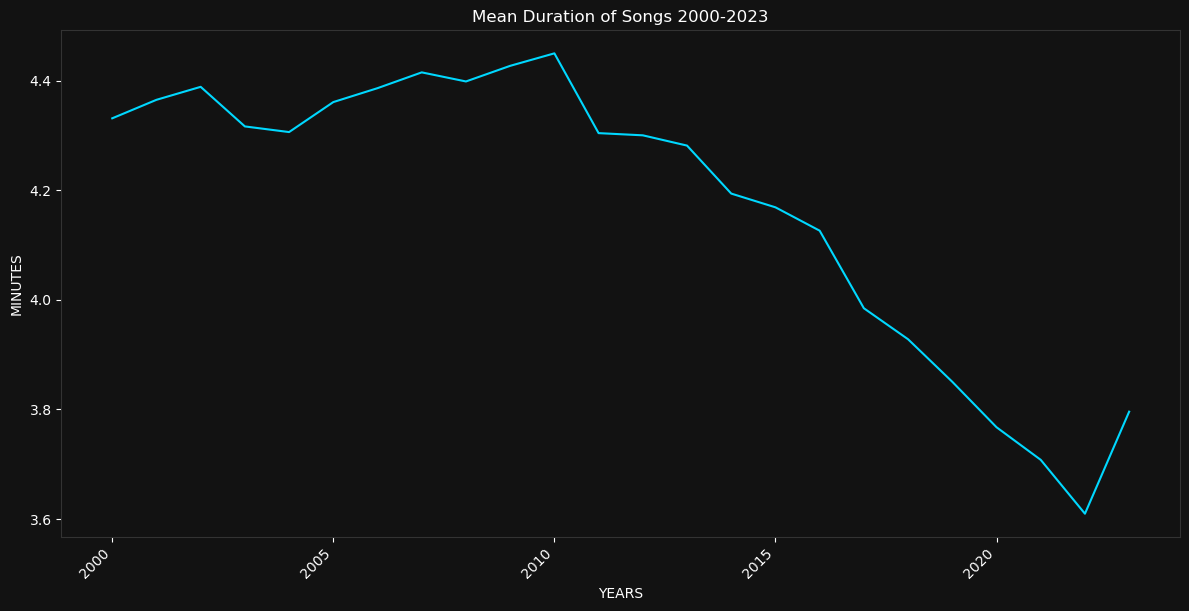

In [69]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=average_min,
    x="year",
    y="average_minutes",
    color='#00d8ff',
)
plt.title('Mean Duration of Songs 2000-2023')
plt.xlabel('YEARS') 
plt.ylabel('MINUTES') 
plt.tight_layout() 
plt.xticks(rotation=45, ha='right')
plt.show()

In this chart is possible to notice the mean songs' duration decreased since the last months of 2009.  
The highest peak was in 2009 when the meann was of 4:30 minutes, meanwhile in 2020 the mean was 3:36 minutes.  
This might be possible for the streaming platforms only replay audio and not musical videos, so it might decreased the time.  
Althought, there are songs with no long instrumental intros or singers prefer to start singing with the instrumental part.

On the other hand, we'll analyze the mean loudness of songs by year in the same way we did with duration.  
We'll create a column named 'avg_loudness' and group by year.  
Loudness is measured in dB.

In [74]:
QUERY13 = """
    SELECT year, AVG(loudness) as avg_loudness
    FROM spotify_db
    GROUP BY year
    ORDER BY year ASC
    """
avg_vol = pd.read_sql_query(QUERY13, conexion)
avg_vol

,year,avg_loudness
0,2000,-10.148483
1,2001,-10.097640
2,2002,-9.587969
3,2003,-9.375994
4,2004,-9.109423
5,2005,-9.267861
6,2006,-9.139491
7,2007,-9.028157
8,2008,-8.763337
9,2009,-8.807054


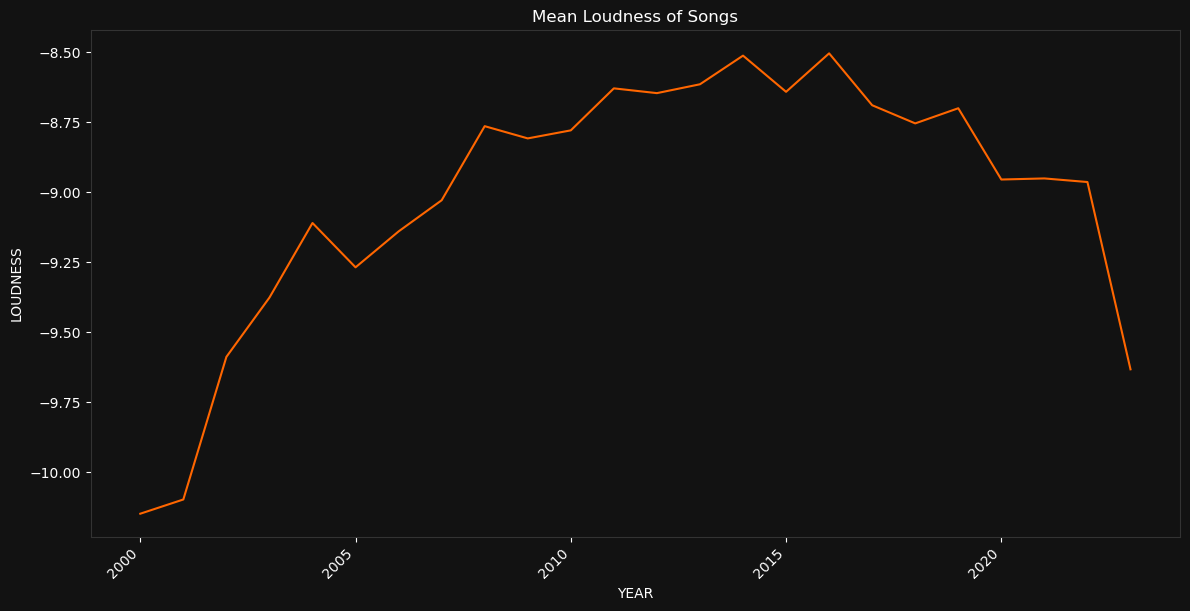

In [76]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=avg_vol,
    x="year",
    y="avg_loudness",
    color='#ff6600',
)
plt.title('Mean Loudness of Songs')
plt.xlabel('YEAR') 
plt.ylabel('LOUDNESS') 
plt.tight_layout() 
plt.xticks(rotation=45, ha='right')
plt.show()

In this graph, it is possible to see at the beginning of the millenium, the mean of loudness was under -10 dB.  
From 2002, the mean increased (except in 2005 when it decreased) and between 2010 and 2016 songs had a average loudness higher, this is known as 'Loudness War'.  
Also, last months of 2009 the average durations of songs decreased meanwhile average loudness increased, this indicates songs sought more retention from the audience being shorter and louder.

En este punto, buscaremos los géneros con un volumen promedio mucho mayor que el resto, es decir, los más "ruidosos".

In [79]:
QUERY14 = """
    SELECT genre, year, AVG(loudness) as avg_loudness
    FROM spotify_db
    WHERE year BETWEEN 2000 AND 2023
      AND genre IN (
          SELECT genre 
          FROM spotify_db 
          WHERE year BETWEEN 2000 AND 2023
          GROUP BY genre 
          ORDER BY AVG(loudness) DESC 
          LIMIT 10
      )
    GROUP BY genre, year
    ORDER BY genre DESC LIMIT 20 
    """
loudest_genres = pd.read_sql_query(QUERY14, conexion)
loudest_genres

,genre,year,avg_loudness
0,punk,2000,-5.044600
1,punk,2002,-5.073480
2,punk,2003,-4.823206
3,punk,2004,-4.993299
4,punk,2005,-4.907781
5,punk,2006,-5.146694
6,punk,2007,-4.851644
7,punk,2008,-5.172552
8,punk,2009,-4.808888
9,punk,2010,-5.043233


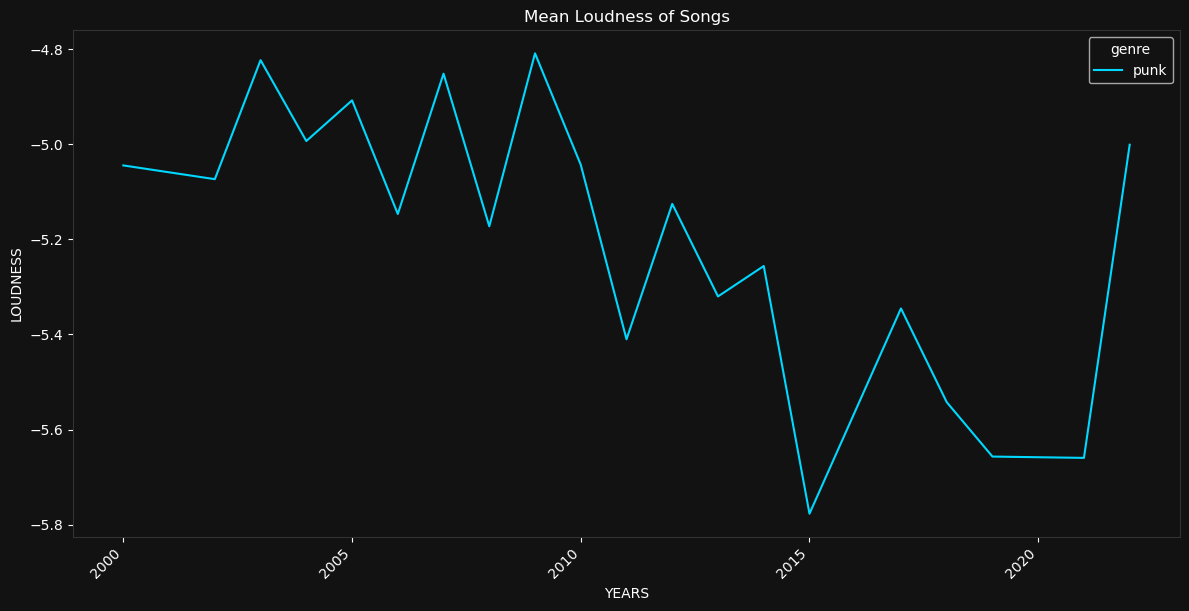

In [81]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=loudest_genres,
    x="year",
    y="avg_loudness",
    hue='genre',
    palette=['#00d8ff'],
)
plt.title('Mean Loudness of Songs')
plt.xlabel('YEARS') 
plt.ylabel('LOUDNESS') 
plt.tight_layout() 
plt.xticks(rotation=45, ha='right')
plt.show()

If we compare the average loudness of Punk with the previuos graph, we can see its average loudness is higher than of the rest of genres in that year.  
Now, we'll see the competitors of Punk in this 'Loudness War'. 

In [84]:
QUERY15 = """
    SELECT 
        genre, 
        year, 
        AVG(loudness) as avg_loudness
    FROM spotify_db
    WHERE year BETWEEN 2000 AND 2023
      AND genre IN (
          SELECT genre 
          FROM spotify_db 
          WHERE year BETWEEN 2000 AND 2023
            AND genre NOT LIKE '%punk%' 
          GROUP BY genre 
          ORDER BY AVG(loudness) DESC 
          LIMIT 10
      )
    GROUP BY genre, year
    ORDER BY year ASC
"""
top_loudest = pd.read_sql_query(QUERY15, conexion)
top_loudest

,genre,year,avg_loudness
0,death-metal,2000,-6.199214
1,drum-and-bass,2000,-8.571186
2,grindcore,2000,-6.256727
3,hard-rock,2000,-6.659988
4,hardcore,2000,-6.233935
...,...,...,...
233,hardstyle,2023,-4.637097
234,heavy-metal,2023,-5.549754
235,metal,2023,-5.381032
236,metalcore,2023,-5.043341


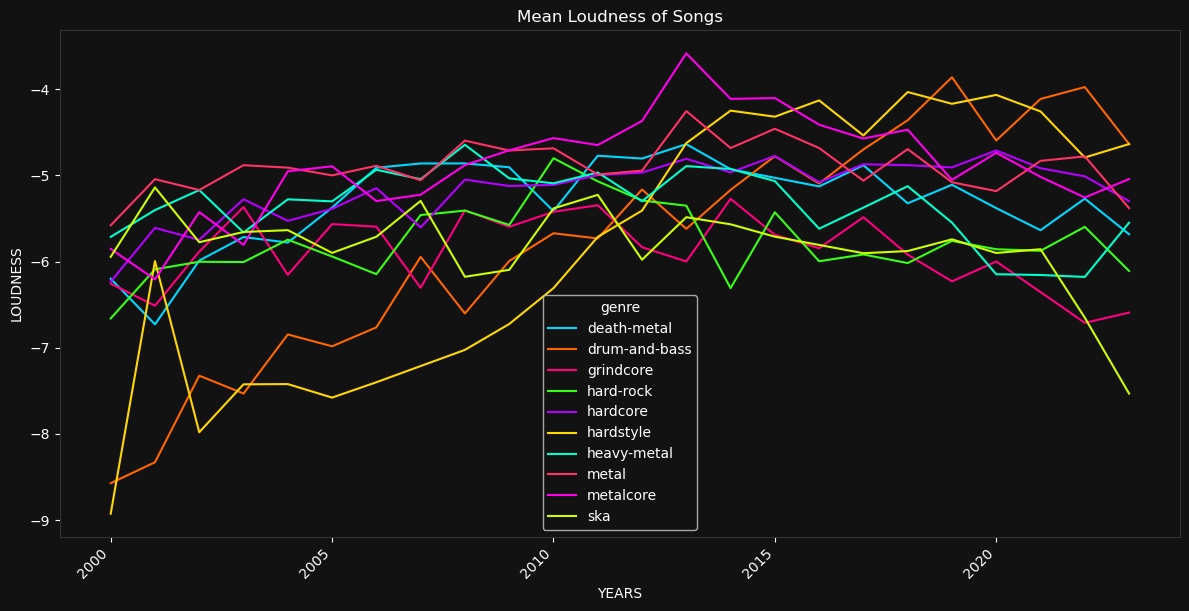

In [86]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=top_loudest,
    x="year",
    y="avg_loudness",
    hue='genre',
    palette=['#00d8ff', 
    '#ff6600',
    '#ff007f',
    '#39ff14',
    '#b500ff', 
    '#ffd700',
    '#00ffcc',
    '#ff3366', 
    '#ff00ea', 
    '#ccff00']
)
plt.title('Mean Loudness of Songs')
plt.xlabel('YEARS') 
plt.ylabel('LOUDNESS') 
plt.tight_layout() 
plt.xticks(rotation=45, ha='right')
plt.show()

We can see that the loudest genres belong to sub-genres of Rock, Metal and Electronic Music, except Ska.  
This be logical for the usage of low frequenc sounds such as electric guitars, synthetic basses, booming kicks and sub-basses, also, the manner of equalizing those songs in their general mix highlight those low frequences that make the songs 'thicker'.  
So, we'll split genres according the category they belong: rock-metal and electronic music.

In [90]:
#grafico de death-metal, heavy-metal, hard-rock, metal-core, punk
QUERY16 = """
    SELECT genre, year, AVG(loudness) as avg_loudness 
    FROM spotify_db
    WHERE genre IN ('death-metal','heavy-metal','metalcore','punk','hard-rock')
    GROUP BY genre, year
    ORDER BY year ASC
    """
top_metal_loudest = pd.read_sql_query(QUERY16, conexion)
top_metal_loudest

,genre,year,avg_loudness
0,death-metal,2000,-6.199214
1,hard-rock,2000,-6.659988
2,heavy-metal,2000,-5.714106
3,metalcore,2000,-5.853305
4,punk,2000,-5.044600
...,...,...,...
111,death-metal,2023,-5.683555
112,hard-rock,2023,-6.109320
113,heavy-metal,2023,-5.549754
114,metalcore,2023,-5.043341


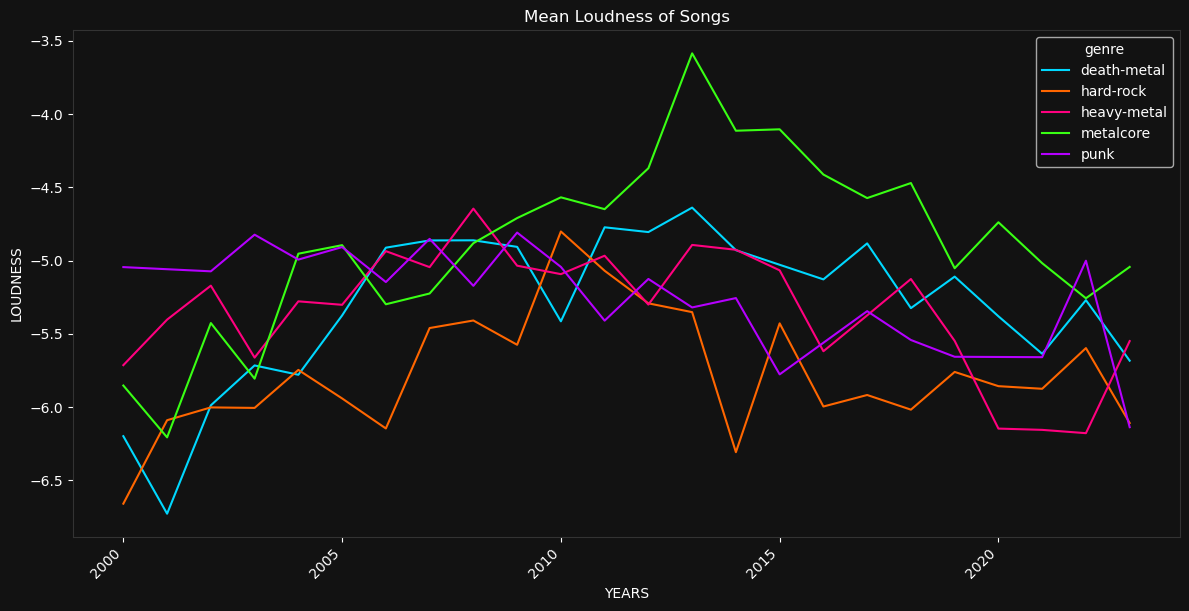

In [92]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=top_metal_loudest,
    x="year",
    y="avg_loudness",
    hue='genre',
    palette=['#00d8ff', # Azul neón 
    '#ff6600', # Naranja 
    '#ff007f', # Rosa cyberpunk
    '#39ff14', # Verde tóxico
    '#b500ff',]
)
plt.title('Mean Loudness of Songs')
plt.xlabel('YEARS') 
plt.ylabel('LOUDNESS')
plt.tight_layout() 
plt.xticks(rotation=45, ha='right')
plt.show()

-It is possible to notice that there is not a clear leader about loudness until 2010, when Metalcore kept on being the 'loudest' genre until it was defeated by Punk.  
-Heavy-Metal always was between -6 and -4.5.  
-Hard-Rock has been one of the most 'discreet' of the list, even when it reached its peak in 2010.  
-Nevertheless, there is a general slope since 2015 of these genres.

In [94]:
QUERY17 = """
    SELECT genre, year, AVG(loudness) as avg_loudness 
    FROM spotify_db
    WHERE genre IN ('drum-and-bass','grindcore','hardcore','hardstyle')
    GROUP BY genre, year
    ORDER BY year ASC
    """
top_metal_electronic = pd.read_sql_query(QUERY17, conexion)
top_metal_electronic

,genre,year,avg_loudness
0,drum-and-bass,2000,-8.571186
1,grindcore,2000,-6.256727
2,hardcore,2000,-6.233935
3,hardstyle,2000,-8.925187
4,drum-and-bass,2001,-8.328342
...,...,...,...
91,hardstyle,2022,-4.793104
92,drum-and-bass,2023,-4.636632
93,grindcore,2023,-6.592661
94,hardcore,2023,-5.298943


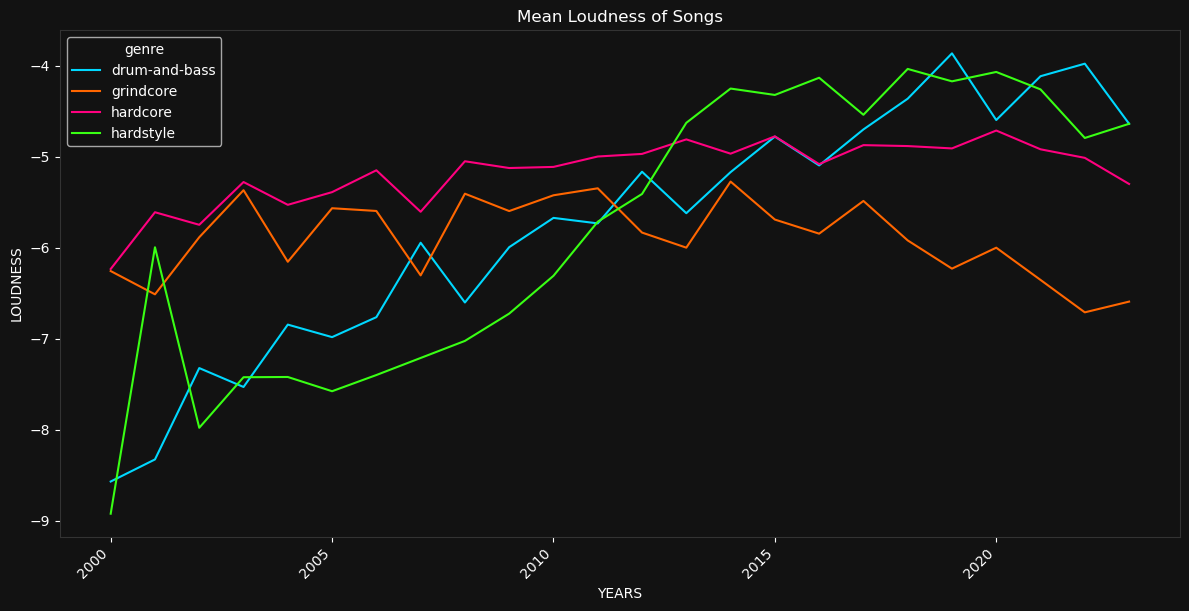

In [96]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=top_metal_electronic,
    x="year",
    y="avg_loudness",
    hue='genre',
    palette=['#00d8ff', # Azul neón 
    '#ff6600', # Naranja 
    '#ff007f', # Rosa cyberpunk
    '#39ff14',] # Verde tóxico
)
plt.title('Mean Loudness of Songs')
plt.xlabel('YEARS') 
plt.ylabel('LOUDNESS')
plt.tight_layout() 
plt.xticks(rotation=45, ha='right')
plt.show()

Elctronic music sub-genres, except Grindcore, kept an average loudness higher than rock-metal sub-genres that were analyzed before.  
-Grindcore has been between -6.5 and -5.5.  
-Hardcore has increased step by step and its lowest record was in 2000 being under -6 dB.  
-On the other hand, Drum-And-Bass (D&B) and HardStyle have had a similar trend through time and are the genres that have compited for loudness.

Which factors make a song to be more successful than others?  
In this point we'll analyze: popularity, danceability, energy, loudness, valence and tempo or BPM (Beats per minute)  
We'll analyze the correlation among those factors to see how much they might influence in success.  
However, it is important to clarify that those characteristics are subjetive, such as, popularity, danceability, energy and valence.

In [101]:
QUERY18 = """
    SELECT popularity, danceability, energy, loudness, valence, tempo 
    FROM spotify_db 
    WHERE popularity IS NOT NULL 
    """
df_audio = pd.read_sql_query(QUERY18, conexion)
df_audio

,popularity,danceability,energy,loudness,valence,tempo
0,68,0.483,0.303,-10.058,0.1390,133.406
1,50,0.572,0.454,-10.286,0.5150,140.182
2,57,0.409,0.234,-13.711,0.1450,139.832
3,58,0.392,0.251,-9.845,0.5080,204.961
4,54,0.430,0.791,-5.419,0.2170,171.864
...,...,...,...,...,...,...
1159759,4,0.373,0.742,-6.453,0.5220,107.951
1159760,3,0.516,0.675,-7.588,0.2640,119.897
1159761,2,0.491,0.440,-8.512,0.0351,100.076
1159762,0,0.480,0.405,-13.343,0.2020,133.885


We'll analyze them with a correlation matrix and a heatmap.

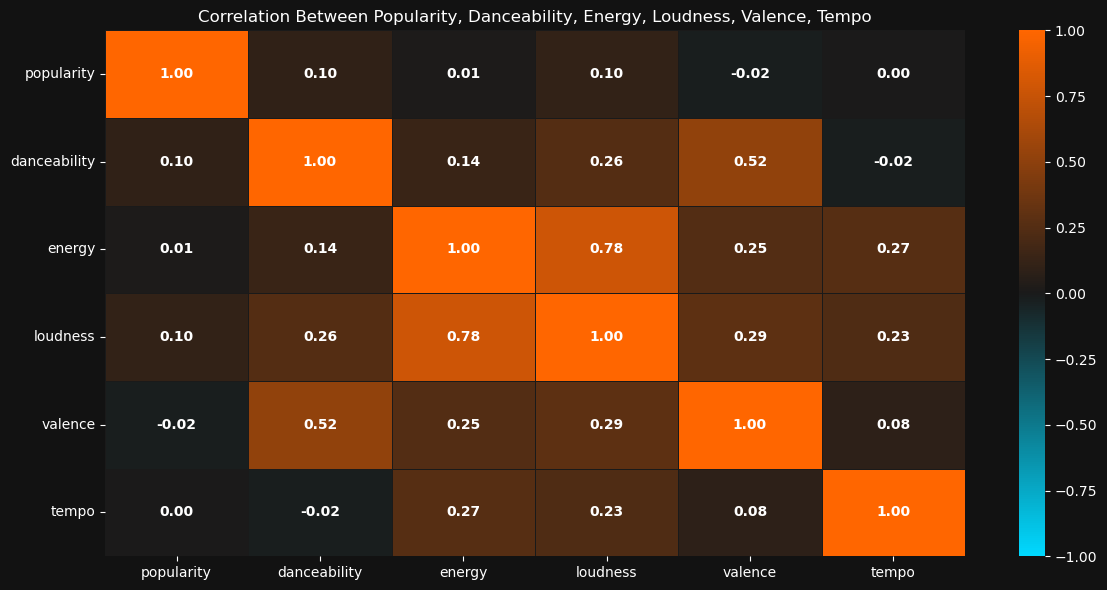

In [104]:
from matplotlib.colors import LinearSegmentedColormap

neon_colors = ['#00d8ff', '#1a1a1a', '#ff6600']
neon_map = LinearSegmentedColormap.from_list('portfolio_style', neon_colors)

matrix = df_audio.corr()
plt.figure(figsize=(12,6))
sns.heatmap(
    matrix,
    annot=True,
    cmap=neon_map,
    fmt='.2f', 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5,
    linecolor='#1a1a1a',      
    annot_kws={"color": "white", "weight": "bold", "size": 10}
)
plt.title('Correlation Between Popularity, Danceability, Energy, Loudness, Valence, Tempo')
plt.tight_layout() 
plt.show()

-It is possible to notive that Energy and Loudness have a close relationship, that's why the Loudness War made sense in its time.  
-However, Popularity and Loudness have a low relationship, to sound loud doesn't guarantee success.  
-Danceability and Valence show a postive but moderated relationship.  
-Tempo and Popularity have a neutral relationship.

Por último, seleccionaremos los 10 géneros musicales más populares a lo largo de este siglo.

In [107]:
QUERY19 = """
    SELECT 
        genre, 
        year, 
        SUM(popularity) as total_popularity
    FROM spotify_db
    WHERE year BETWEEN 2000 AND 2023
      AND genre IN (
          SELECT genre 
          FROM spotify_db 
          WHERE year BETWEEN 2000 AND 2023
          GROUP BY genre 
          ORDER BY SUM(popularity) DESC 
          LIMIT 10
      )
    GROUP BY genre, year
    ORDER BY year ASC
"""
top_trends = pd.read_sql_query(QUERY19, conexion)
top_trends

,genre,year,total_popularity
0,alt-rock,2000,30252
1,chill,2000,384
2,country,2000,17144
3,dance,2000,26604
4,emo,2000,7614
...,...,...,...
233,folk,2023,14200
234,french,2023,21835
235,hip-hop,2023,16547
236,jazz,2023,23566


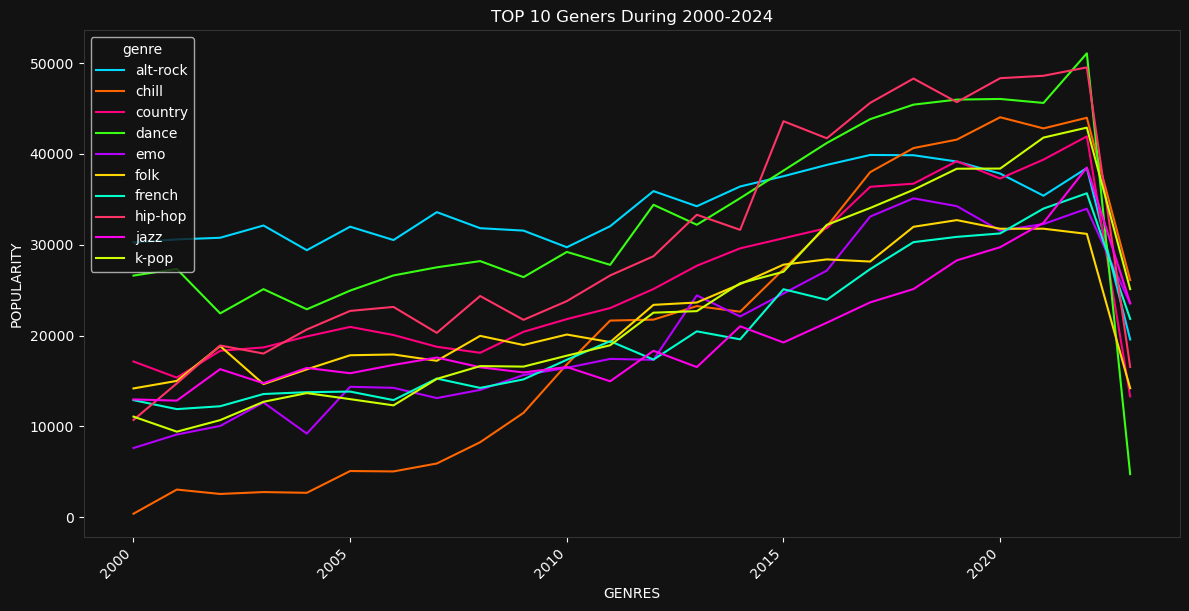

In [111]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=top_trends,
    x="year",
    y="total_popularity",
    hue='genre',
    palette=['#00d8ff',
    '#ff6600', 
    '#ff007f', 
    '#39ff14', 
    '#b500ff',
    '#ffd700', 
    '#00ffcc',
    '#ff3366',
    '#ff00ea', 
    '#ccff00']
)
plt.title('TOP 10 Geners During 2000-2024')
plt.xlabel('GENRES') 
plt.ylabel('POPULARITY') 
plt.tight_layout() 
plt.xticks(rotation=45, ha='right')
plt.show()

With this chart, we can conclude that there are genres that have remained inside TOP 10, such as, Alt-Rock, Country, Dance, Hip-Hop and Jazz and French music.  
Meanwhile, Chill became popular step by step.  
Note: the general slope in the last year does not represent a real fall in consumption, but the cut of data collection from database (incomplete year), so it reduces the total popularity aggregated against the last years.